Ce notebook a été entièrement réalise par Enzo Nguyen

# Améliorations — Prédiction de redshift avec CNN pré-entraîné + Auto-encodeurs

Ce notebook applique les améliorations identifiées dans `VIF + auto encodeur - pretrained.ipynb` :

1. **PCA** sur les features CNN (réduction 1024 → N composantes)
2. **Prédiction directe** du CNN via `out_reg`
3. **Ridge** au lieu de Random Forest
4. **VIF** pour analyser la redondance linéaire entre features
5. **σ_NMAD** comme métrique robuste
6. **Features 96-dim** (couche `reduction`, avant les FC)
7. **Bootstrap** pour intervalles de confiance
8. **Auto-encodeur convolutionnel** sur les cubes d'images (64×64×9)
9. **Auto-encodeur MLP** sur les magnitudes photométriques

In [1]:
try:
    import gdown
except ImportError:
    import os
    os.system("pip install -q gdown")
    import gdown

import os
import glob
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.utils import resample
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

## 1. Chargement et préparation des données

In [2]:
import pathlib

# Place le répertoire de travail au même endroit que ce notebook
_nb_dir = pathlib.Path(r"c:\Users\nguye\Desktop\Enzo\Cours\M1 MIASHS\TER - Redshift")
if _nb_dir.exists():
    os.chdir(_nb_dir)
print(f"Répertoire de travail : {os.getcwd()}")

dossier_nom = "redshift"
url = "https://drive.google.com/drive/folders/1-tQH6rfB1XoF7ml98yqVn7Z2IQwGMUdK?usp=sharing"

fichiers_npz  = glob.glob(os.path.join(dossier_nom, "*.npz"))
cosmos_files  = [f for f in fichiers_npz if "COSMOS" in f]

if len(cosmos_files) >= 4:
    print(f"Données déjà présentes ({len(cosmos_files)} fichiers COSMOS).")
else:
    print(f"Seulement {len(cosmos_files)} fichier(s) trouvé(s). Tentative de téléchargement...")
    try:
        gdown.download_folder(url, quiet=False, use_cookies=False)
    except Exception as e:
        print(f"\n⚠ gdown bloqué : {e}")
        print("→ Télécharge manuellement depuis : " + url)
        print("→ Place les 4 fichiers COSMOS .npz dans le dossier 'redshift/'")

fichiers_npz = glob.glob(os.path.join(dossier_nom, "*.npz"))
cosmos_files = [f for f in fichiers_npz if "COSMOS" in f]
print(f"\nFichiers COSMOS disponibles ({len(cosmos_files)}) :")
for f in cosmos_files:
    print(f"  {f}")

if not cosmos_files:
    raise ValueError("Aucun fichier COSMOS trouvé. Télécharge les données manuellement.")

data_list = []
for f in cosmos_files:
    try:
        data_list.append(np.load(f, allow_pickle=True))
        print(f"Chargé : {f}")
    except Exception as e:
        print(f"Erreur : {f} -> {e}")

Répertoire de travail : /content
Seulement 0 fichier(s) trouvé(s). Tentative de téléchargement...


Retrieving folder contents


Retrieving folder 1mqIUBkZ3qN82hQ3H5WEdz0YYggMxZe3J Marie Treyer
Retrieving folder 1cYT_5mdowwVmTBKE4tk81cvTZH1wgF1z utils
Processing file 1vVGNrMt08Zv0L5L9Jj2VBQ_Wr3xSctXD config.py
Processing file 1lP36XyZXAzWo4bWUeRX47zHS2-66Egiu model_multi_modal_simple.py
Processing file 1EJbuWKWelcDNSbwqb5XYzae-tm3RovWJ models_building_blocks.py
Retrieving folder 11o2WZw9RevBiuMPZiU7RYpBM4jMgJE_v tmp_csv
Processing file 1-L71kr1PPPfMs9LmMj3Gwb7471pWzEKi COSMOS_v11_uijk_0001_photo_D_flag.csv
Processing file 1kwGxs5CNz4b4dia0e5WvMA0PQE5AkwzW COSMOS_v11_uijk_0001_photo_D_info.csv
Processing file 1o_lFj4sLD6gC4p2Uh5tUMpA68X9KWzQL COSMOS_v11_uijk_0020_spec_D_cube.csv
Processing file 1inUo1fii_Aa_nLkp0IfpCUwt0aFZpD3Y COSMOS_v11_uijk_0020_spec_D_flag.csv
Processing file 1vysgUr-ZuXio9FDOD3ODggd01qkV0_hi COSMOS_v11_uijk_0020_spec_D_info.csv
Processing file 1nA4LfjIDfgM7YNRphu8ONxX1yUlEqBTn COSMOS_v11_uijk_0073_spec_UD_cube.csv
Processing file 11y1VpyAPWvCwFAqnbSJ_ukHR4szF6ne_ COSMOS_v11_uijk_0073_spec_UD

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1vVGNrMt08Zv0L5L9Jj2VBQ_Wr3xSctXD
From (redirected): https://drive.google.com/uc?id=1vVGNrMt08Zv0L5L9Jj2VBQ_Wr3xSctXD&confirm=t&uuid=72335351-ca1f-4b1a-806c-5255c5cffd40
To: /content/redshift/Marie Treyer/utils/config.py
100%|██████████| 2.79k/2.79k [00:00<00:00, 9.23MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1lP36XyZXAzWo4bWUeRX47zHS2-66Egiu
From (redirected): https://drive.google.com/uc?id=1lP36XyZXAzWo4bWUeRX47zHS2-66Egiu&confirm=t&uuid=0b8b99cc-3db2-4eb4-af26-2e469044834e
To: /content/redshift/Marie Treyer/model_multi_modal_simple.py
100%|██████████| 20.6k/20.6k [00:00<00:00, 43.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1EJbuWKWelcDNSbwqb5XYzae-tm3RovWJ
From (redirected): https://drive.google.com/uc?id=1EJbuWKWelcDNSbwqb5XYzae-tm3RovWJ&confirm=t&uuid=36563229-5640


Fichiers COSMOS disponibles (4) :
  redshift/COSMOS_v11_uijk_0001_photo_D.npz
  redshift/COSMOS_v11_uijk_0020_spec_D.npz
  redshift/COSMOS_v11_uijk_0213_photo_UD.npz
  redshift/COSMOS_v11_uijk_0073_spec_UD.npz
Chargé : redshift/COSMOS_v11_uijk_0001_photo_D.npz
Chargé : redshift/COSMOS_v11_uijk_0020_spec_D.npz
Chargé : redshift/COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : redshift/COSMOS_v11_uijk_0073_spec_UD.npz



Download completed


In [3]:
bands = ["u", "g", "r", "i", "z", "y", "J", "H"]

mags_list, zspec_list, zphot_list, cube_list, flag_list = [], [], [], [], []
for d in data_list:
    info = d['info']
    mags_list.append(np.column_stack([info[b] for b in bands]))
    zphot_list.append(info['ZPHOT'])
    cube_list.append(d['cube'])
    flag_list.append(d['flag'])
    try:
        zspec_list.append(info['ZSPEC'])
    except ValueError:
        zspec_list.append(np.full(info.shape[0], np.nan))

all_mags  = np.vstack(mags_list)
all_zphot = np.hstack(zphot_list)
all_zspec = np.hstack(zspec_list)
all_cubes = np.vstack(cube_list)
all_flags = np.vstack(flag_list)

mask_mags = (all_mags < 0) | (all_mags > 40)
all_mags[mask_mags] = np.nan
all_mags[np.abs(stats.zscore(all_mags, nan_policy='omit')) > 3] = np.nan
with np.errstate(invalid='ignore'):
    all_zspec[np.isnan(all_zspec) | (all_zspec < 0) | (all_zspec > 6)] = np.nan
    all_zphot[(all_zphot < 0) | (all_zphot > 6)] = np.nan

variances = np.nanvar(all_mags, axis=0)
valid_idx = np.where(variances > 0)[0]
all_mags  = all_mags[:, valid_idx]
bands     = [bands[i] for i in valid_idx]

col_medians = np.nanmedian(all_mags, axis=0)
nan_mask    = np.isnan(all_mags)
all_mags[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

colors      = np.diff(all_mags, axis=1)
color_names = [f"{bands[i]}-{bands[i+1]}" for i in range(len(bands) - 1)]

mask_test  = ~np.isnan(all_zspec) & (all_zspec > 0)
mask_train = (~mask_test) & (~np.isnan(all_zphot)) & (all_zphot > 0)
y_train    = all_zphot[mask_train]
y_test     = all_zspec[mask_test]

print(f"Magnitudes : {all_mags.shape}  |  Couleurs : {colors.shape}")
print(f"Train (ZPHOT) : {mask_train.sum()}  |  Test (ZSPEC) : {mask_test.sum()}")

Magnitudes : (12524, 8)  |  Couleurs : (12524, 7)
Train (ZPHOT) : 12497  |  Test (ZSPEC) : 27


## 2. Architecture CNN pré-entraîné et chargement des poids

In [4]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, archi=(109, 101, 101, 101, 156, 156)):
        super().__init__()
        b4_out, b1_mid, b2_mid, b3_out, b2_out, b1_out = archi
        self.b1_1x1 = nn.Sequential(nn.Conv2d(in_channels, b1_mid, 1), nn.BatchNorm2d(b1_mid))
        self.b1_5x5 = nn.Sequential(nn.Conv2d(b1_mid, b1_out, 5, padding=2), nn.BatchNorm2d(b1_out))
        self.b2_1x1 = nn.Sequential(nn.Conv2d(in_channels, b2_mid, 1), nn.BatchNorm2d(b2_mid))
        self.b2_3x3 = nn.Sequential(nn.Conv2d(b2_mid, b2_out, 3, padding=1), nn.BatchNorm2d(b2_out))
        self.b3_1x1 = nn.Sequential(nn.Conv2d(in_channels, b3_out, 1), nn.BatchNorm2d(b3_out))
        self.b4_1x1 = nn.Sequential(nn.Conv2d(in_channels, b4_out, 1), nn.BatchNorm2d(b4_out))

    def forward(self, x):
        b1 = F.relu(self.b1_5x5(F.relu(self.b1_1x1(x))))
        b2 = F.relu(self.b2_3x3(F.relu(self.b2_1x1(x))))
        b3 = F.relu(self.b3_1x1(x))
        b4 = F.relu(self.b4_1x1(x))
        return torch.cat([b1, b2, b3, b4], dim=1)


class PhotZMultiScale(nn.Module):
    INCEPTION_CH = 522

    def __init__(self, in_channels=9, stem_ch=96, n_pdf=180):
        super().__init__()
        C = self.INCEPTION_CH
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stem_ch, 5, padding=2), nn.BatchNorm2d(stem_ch), nn.ReLU(),
            nn.Conv2d(stem_ch, stem_ch, 3, padding=1),     nn.BatchNorm2d(stem_ch), nn.ReLU(),
        )
        self.scale32   = nn.Sequential(InceptionBlock(stem_ch), InceptionBlock(C))
        self.scale16   = nn.Sequential(InceptionBlock(C), InceptionBlock(C), InceptionBlock(C))
        self.scale8    = InceptionBlock(C)
        self.reduction = nn.Sequential(
            nn.Conv2d(C, stem_ch, 3),       nn.BatchNorm2d(stem_ch), nn.ReLU(),
            nn.Conv2d(stem_ch, stem_ch, 3), nn.BatchNorm2d(stem_ch), nn.ReLU(),
            nn.Conv2d(stem_ch, stem_ch, 3), nn.BatchNorm2d(stem_ch), nn.ReLU(),
            nn.AvgPool2d(2, stride=2),
        )
        self.fc1     = nn.Sequential(nn.Linear(stem_ch + 1, 1024), nn.ReLU())
        self.fc2     = nn.Sequential(nn.Linear(1024, 1024), nn.ReLU())
        self.fc3     = nn.Sequential(nn.Linear(1024, 512),  nn.ReLU())
        self.out_pdf = nn.Linear(1024, n_pdf)
        self.out_reg = nn.Linear(512,  1)

    def _backbone(self, x):
        x = self.stem(x)
        x = F.avg_pool2d(x, 2, 2)
        x = self.scale32(x)
        x = F.avg_pool2d(x, 2, 2)
        x = self.scale16(x)
        x = F.avg_pool2d(x, 2, 2)
        x = self.scale8(x)
        x = self.reduction(x)
        return x.flatten(1)

    def _fc_input(self, x):
        feats = self._backbone(x)
        ebv   = torch.zeros(feats.size(0), 1, device=feats.device)
        return torch.cat([feats, ebv], dim=1)

    def forward(self, x):
        h  = self.fc1(self._fc_input(x))
        h2 = self.fc2(h)
        return self.out_pdf(h2), self.out_reg(self.fc3(h2))

    def features_96(self, x):   return self._backbone(x)
    def features_1024(self, x): return self.fc2(self.fc1(self._fc_input(x)))
    def predict_z(self, x):     return self.forward(x)[1]

In [5]:
def preprocess_cubes(cubes, flags):
    c = cubes.copy().astype(np.float32)
    mask = (flags >= 5)[:, np.newaxis, np.newaxis, :]
    c[np.broadcast_to(mask, c.shape)] = 0.0
    return np.sign(c) * (np.sqrt(np.abs(c) + 1) - 1)

cubes_t      = np.transpose(preprocess_cubes(all_cubes, all_flags), (0, 3, 1, 2))
tensor_cubes = torch.nan_to_num(torch.FloatTensor(cubes_t), nan=0.0, posinf=0.0, neginf=0.0)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cnn = PhotZMultiScale().to(device)

pt_path = os.path.join("redshift", "best_photoz_model.pt")
weights_loaded = False
if os.path.exists(pt_path):
    state = torch.load(pt_path, map_location=device, weights_only=False)
    missing, unexpected = model_cnn.load_state_dict(state, strict=False)
    n_ok = len(model_cnn.state_dict()) - len(missing)
    weights_loaded = n_ok > 10
    print(f"Poids CNN [{('OK' if weights_loaded else 'ECHOUE')}] : {n_ok}/{len(model_cnn.state_dict())} couches")
else:
    print(f"Fichier non trouvé : {pt_path}")

model_cnn.eval()
print(f"Device : {device}")

Poids CNN [OK] : 297/297 couches
Device : cuda


## 3. Extraction des features CNN

In [6]:
def extract_all(model, tensor_cubes, device, batch_size=32):
    loader = DataLoader(TensorDataset(tensor_cubes), batch_size=batch_size, shuffle=False)
    f96, f1024, zpred = [], [], []
    with torch.no_grad():
        for (b,) in loader:
            b = b.to(device)
            f96.append(model.features_96(b).cpu().numpy())
            f1024.append(model.features_1024(b).cpu().numpy())
            zpred.append(model.predict_z(b).cpu().numpy())
    return np.vstack(f96), np.vstack(f1024), np.vstack(zpred).flatten()

feats_96, feats_1024, zphot_cnn = extract_all(model_cnn, tensor_cubes, device)
print(f"Features 96-dim   : {feats_96.shape}")
print(f"Features 1024-dim : {feats_1024.shape}")
print(f"Prédictions CNN   : {zphot_cnn.shape}")

Features 96-dim   : (12524, 96)
Features 1024-dim : (12524, 1024)
Prédictions CNN   : (12524,)


---
## 4. VIF — Analyse de redondance linéaire

Le **VIF (Variance Inflation Factor)** mesure à quel point une feature est linéairement prévisible depuis les autres.

- **VIF < 5** : pas de colinéarité → feature indépendante, à conserver
- **VIF 5–10** : colinéarité modérée → à surveiller
- **VIF > 10** : colinéarité forte → feature redondante, à éliminer

On calcule le VIF sur trois groupes : magnitudes, couleurs, et features CNN (via PCA-15 pour réduire la dimension).

VIF — Magnitudes :
Feature      VIF
      u 2.274201
      g 5.111038
      r 7.838231
      i 9.106819
      z 7.636176
      y 3.958228
      J 1.649752
      H 1.651012

VIF — Couleurs :
Feature      VIF
    u-g 1.133477
    g-r 1.197869
    r-i 1.351920
    i-z 1.497905
    z-y 1.530822
    y-J 1.627062
    J-H 1.004972

VIF — Features CNN 96-dim (après PCA-15) :
Feature  VIF
    PC1  1.0
    PC2  1.0
    PC3  1.0
    PC4  1.0
    PC5  1.0
    PC6  1.0
    PC7  1.0
    PC8  1.0
    PC9  1.0
   PC10  1.0
   PC11  1.0
   PC12  1.0
   PC13  1.0
   PC14  1.0
   PC15  1.0


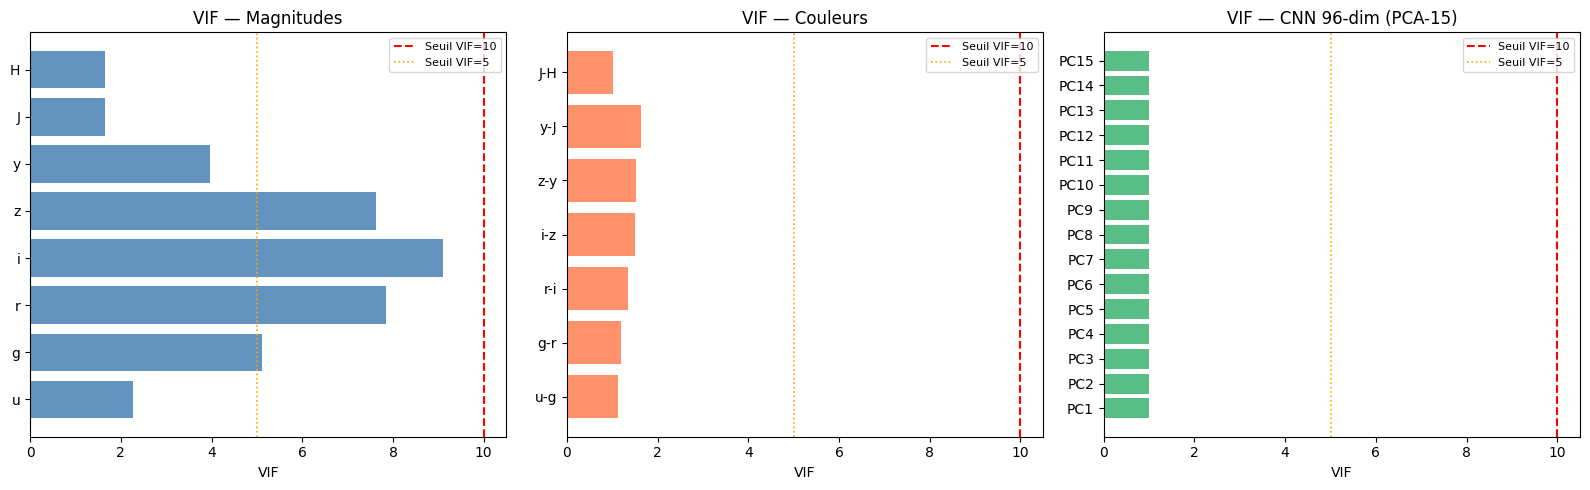


Règle : VIF < 5 = OK  |  5-10 = attention  |  > 10 = colinéarité problématique


In [7]:
def compute_vif(matrix, names):
    df = pd.DataFrame(matrix, columns=names)
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    df['const'] = 1.0
    vif_vals = [variance_inflation_factor(df.values, i) for i in range(len(names))]
    return pd.DataFrame({"Feature": names, "VIF": vif_vals})

mags_scaled   = StandardScaler().fit_transform(all_mags)
colors_scaled = StandardScaler().fit_transform(colors)

print("VIF — Magnitudes :")
vif_mags = compute_vif(mags_scaled, bands)
print(vif_mags.to_string(index=False))

print("\nVIF — Couleurs :")
vif_colors = compute_vif(colors_scaled, color_names)
print(vif_colors.to_string(index=False))

print("\nVIF — Features CNN 96-dim (après PCA-15) :")
pca15     = PCA(n_components=15).fit_transform(StandardScaler().fit_transform(feats_96))
pca_names = [f"PC{i+1}" for i in range(15)]
vif_cnn   = compute_vif(pca15, pca_names)
print(vif_cnn.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, vif_df, title, color in [
    (axes[0], vif_mags,   "Magnitudes",        "steelblue"),
    (axes[1], vif_colors, "Couleurs",           "coral"),
    (axes[2], vif_cnn,    "CNN 96-dim (PCA-15)", "mediumseagreen"),
]:
    finite = vif_df[np.isfinite(vif_df["VIF"])]
    ax.barh(finite["Feature"], finite["VIF"], color=color, alpha=0.85)
    ax.axvline(10, color="red", linestyle="--", lw=1.5, label="Seuil VIF=10")
    ax.axvline(5,  color="orange", linestyle=":",  lw=1.2, label="Seuil VIF=5")
    ax.set_xlabel("VIF")
    ax.set_title(f"VIF — {title}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nRègle : VIF < 5 = OK  |  5-10 = attention  |  > 10 = colinéarité problématique")

## 5. Métriques robustes

In [8]:
def sigma_nmad(z_true, z_pred):
    dz = (z_pred - z_true) / (1 + z_true)
    return 1.4826 * np.median(np.abs(dz - np.median(dz)))

def outlier_rate(z_true, z_pred, threshold=0.15):
    return np.mean(np.abs(z_pred - z_true) / (1 + z_true) > threshold)

def evaluate(z_true, z_pred, name=""):
    r2   = r2_score(z_true, z_pred)
    nmad = sigma_nmad(z_true, z_pred)
    eta  = outlier_rate(z_true, z_pred)
    print(f"  {name:<42}  R²={r2:+.4f}  σ_NMAD={nmad:.4f}  η={eta:.2f}")
    return {"name": name, "r2": r2, "nmad": nmad, "eta": eta}

def bootstrap_r2(z_true, z_pred, n_boot=1000):
    idx = np.arange(len(z_true))
    scores = []
    for _ in range(n_boot):
        s = resample(idx)
        try:
            scores.append(r2_score(z_true[s], z_pred[s]))
        except Exception:
            pass
    return np.percentile(scores, [2.5, 97.5])

## 6. Prédiction directe CNN + Baselines

In [9]:
print("=== Baselines ===")
res_zphot  = evaluate(y_test, all_zphot[mask_test],  "ZPHOT classique")
res_direct = evaluate(y_test, zphot_cnn[mask_test],  "Prédiction directe CNN")

print("\n=== Random Forest ===")
feature_sets_rf = {
    "Magnitudes seules"       : all_mags,
    "Couleurs seules"         : colors,
    "Features CNN 96-dim"     : feats_96,
    "Couleurs + CNN 96-dim"   : np.hstack([colors, feats_96]),
    "Couleurs + CNN 1024-dim" : np.hstack([colors, feats_1024]),
}
rf_results = {}
for name, X in feature_sets_rf.items():
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X[mask_train], y_train)
    r = evaluate(y_test, rf.predict(X[mask_test]), name)
    rf_results[name] = r

=== Baselines ===
  ZPHOT classique                             R²=+0.6609  σ_NMAD=0.0665  η=0.30
  Prédiction directe CNN                      R²=-0.0691  σ_NMAD=0.6553  η=0.93

=== Random Forest ===
  Magnitudes seules                           R²=+0.4259  σ_NMAD=0.3466  η=0.59
  Couleurs seules                             R²=+0.6037  σ_NMAD=0.2702  η=0.67
  Features CNN 96-dim                         R²=-0.0035  σ_NMAD=0.4200  η=0.74
  Couleurs + CNN 96-dim                       R²=+0.3782  σ_NMAD=0.3689  η=0.63
  Couleurs + CNN 1024-dim                     R²=+0.3239  σ_NMAD=0.4282  η=0.59


## 7. PCA + Random Forest

In [10]:
print("=== PCA sur features 1024-dim + Random Forest ===")
pca_results = []
for n_comp in [5, 10, 20, 50, 100]:
    cnn_r = PCA(n_components=n_comp).fit_transform(
        StandardScaler().fit_transform(feats_1024)
    )
    X_tr = np.hstack([colors[mask_train], cnn_r[mask_train]])
    X_te = np.hstack([colors[mask_test],  cnn_r[mask_test]])
    rf   = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    pca_results.append(evaluate(y_test, rf.predict(X_te), f"Couleurs + CNN PCA-{n_comp}"))

=== PCA sur features 1024-dim + Random Forest ===
  Couleurs + CNN PCA-5                        R²=+0.4260  σ_NMAD=0.2943  η=0.67
  Couleurs + CNN PCA-10                       R²=+0.4288  σ_NMAD=0.2412  η=0.63
  Couleurs + CNN PCA-20                       R²=+0.4191  σ_NMAD=0.3069  η=0.74
  Couleurs + CNN PCA-50                       R²=+0.4097  σ_NMAD=0.2623  η=0.74
  Couleurs + CNN PCA-100                      R²=+0.4015  σ_NMAD=0.2426  η=0.74


## 8. Bootstrap — Intervalles de confiance

In [11]:
print(f"  {'Méthode':<42}  R²        IC 95%")
print("  " + "-" * 72)

boot_configs = [("ZPHOT classique", all_zphot[mask_test]),
                ("Prédiction directe CNN", zphot_cnn[mask_test])]
for name, X in feature_sets_rf.items():
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X[mask_train], y_train)
    boot_configs.append((f"RF — {name}", rf.predict(X[mask_test])))

boot_results = []
for name, preds in boot_configs:
    ci  = bootstrap_r2(y_test, preds)
    r2m = r2_score(y_test, preds)
    print(f"  {name:<42}  {r2m:+.4f}    [{ci[0]:+.3f}, {ci[1]:+.3f}]")
    boot_results.append({"name": name, "r2": r2m, "ci_low": ci[0], "ci_high": ci[1]})

  Méthode                                     R²        IC 95%
  ------------------------------------------------------------------------
  ZPHOT classique                             +0.6609    [+0.431, +0.937]
  Prédiction directe CNN                      -0.0691    [-0.746, +0.010]
  RF — Magnitudes seules                      +0.4259    [+0.203, +0.698]
  RF — Couleurs seules                        +0.6037    [+0.468, +0.767]
  RF — Features CNN 96-dim                    -0.0035    [-0.567, +0.208]
  RF — Couleurs + CNN 96-dim                  +0.3782    [+0.117, +0.561]
  RF — Couleurs + CNN 1024-dim                +0.3239    [-0.102, +0.514]


---
## 9. Auto-encodeur A — Convolutionnel (images 64×64×9)

Un auto-encodeur compresse les données puis les reconstruit :
```
Image → Encodeur → Code latent Z (32-dim) → Décodeur → Image reconstruite
```
Entraîné de façon **non supervisée** sur toutes les galaxies (pas besoin de ZPHOT/ZSPEC).
Le code latent Z capture les structures morphologiques les plus importantes.

**Architecture :**
```
Encodeur : (9,64,64) → Conv+Pool×4 → Flatten → Linear → (32,)
Décodeur : (32,) → Linear → Reshape → ConvTranspose×4 → (9,64,64)
```

In [12]:
class ConvEncoder(nn.Module):
    def __init__(self, in_channels=9, latent_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            # (9, 64, 64) → (16, 32, 32)
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.AvgPool2d(2),
            # (16, 32, 32) → (32, 16, 16)
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AvgPool2d(2),
            # (32, 16, 16) → (64, 8, 8)
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AvgPool2d(2),
            # (64, 8, 8) → (32, 4, 4)
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.AvgPool2d(2),
        )
        self.fc = nn.Linear(32 * 4 * 4, latent_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class ConvDecoder(nn.Module):
    def __init__(self, out_channels=9, latent_dim=32):
        super().__init__()
        self.fc  = nn.Linear(latent_dim, 32 * 4 * 4)
        self.net = nn.Sequential(
            # (32, 4, 4) → (64, 8, 8)
            nn.ConvTranspose2d(32, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            # (64, 8, 8) → (32, 16, 16)
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            # (32, 16, 16) → (16, 32, 32)
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            # (16, 32, 32) → (9, 64, 64)
            nn.ConvTranspose2d(16, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, z):
        return self.net(self.fc(z).view(-1, 32, 4, 4))


class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=9, latent_dim=32):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim)
        self.decoder = ConvDecoder(in_channels, latent_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


print("Architecture ConvAutoencoder prête.")
print(f"  Encodeur : (N, 9, 64, 64) → (N, 32)")
print(f"  Décodeur : (N, 32) → (N, 9, 64, 64)")

Architecture ConvAutoencoder prête.
  Encodeur : (N, 9, 64, 64) → (N, 32)
  Décodeur : (N, 32) → (N, 9, 64, 64)


In [13]:
LATENT_DIM_CONV = 32
EPOCHS_CONV     = 30
LR_CONV         = 1e-3
BATCH_CONV      = 64

conv_ae   = ConvAutoencoder(latent_dim=LATENT_DIM_CONV).to(device)
opt_conv  = optim.Adam(conv_ae.parameters(), lr=LR_CONV)
crit_conv = nn.MSELoss()
loader_ae = DataLoader(TensorDataset(tensor_cubes), batch_size=BATCH_CONV, shuffle=True)

losses_conv = []
for epoch in range(EPOCHS_CONV):
    conv_ae.train()
    epoch_loss = 0.0
    for (xb,) in loader_ae:
        xb = xb.to(device)
        opt_conv.zero_grad()
        loss = crit_conv(conv_ae(xb), xb)
        loss.backward()
        opt_conv.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(tensor_cubes)
    losses_conv.append(epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS_CONV}  MSE={epoch_loss:.5f}")

print(f"\nEntraînement terminé. MSE finale = {losses_conv[-1]:.5f}")

  Epoch   5/30  MSE=0.02256
  Epoch  10/30  MSE=0.02047
  Epoch  15/30  MSE=0.02145
  Epoch  20/30  MSE=0.01824
  Epoch  25/30  MSE=0.01292
  Epoch  30/30  MSE=0.01116

Entraînement terminé. MSE finale = 0.01116


Codes latents convolutionnels : (12524, 32)


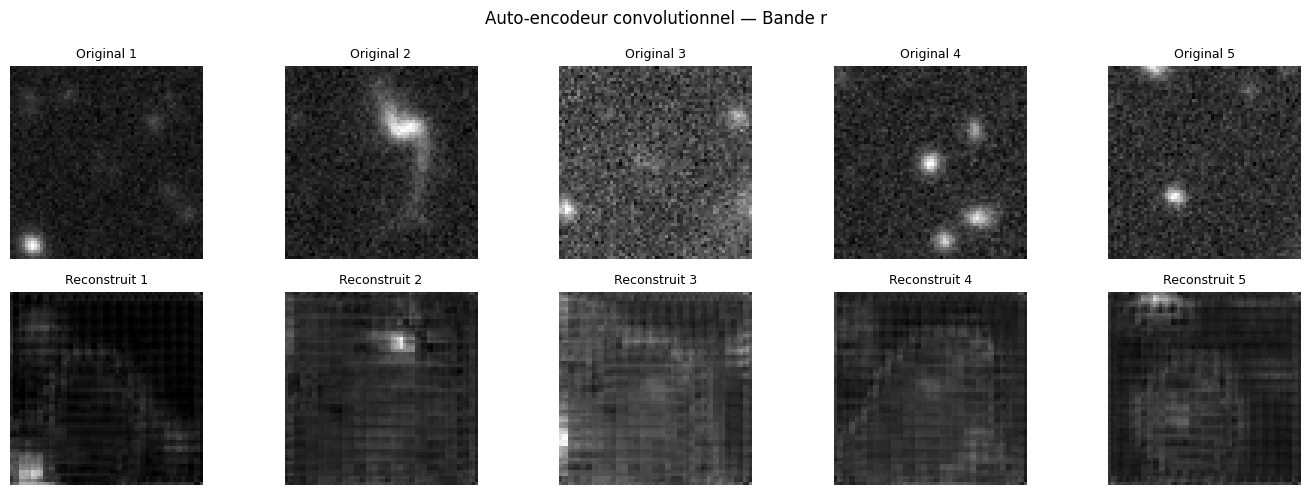

In [14]:
# Extraction des codes latents convolutionnels
conv_ae.eval()
latent_conv_list = []
loader_eval = DataLoader(TensorDataset(tensor_cubes), batch_size=64, shuffle=False)

with torch.no_grad():
    for (xb,) in loader_eval:
        latent_conv_list.append(conv_ae.encode(xb.to(device)).cpu().numpy())

latent_conv = np.vstack(latent_conv_list)   # (12524, 32)
print(f"Codes latents convolutionnels : {latent_conv.shape}")

# Visualisation : reconstruction de quelques galaxies
n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(14, 5))
sample_idx = np.random.choice(len(tensor_cubes), n_show, replace=False)

with torch.no_grad():
    sample_batch = tensor_cubes[sample_idx].to(device)
    reconstructed = conv_ae(sample_batch).cpu().numpy()
    originals     = tensor_cubes[sample_idx].numpy()

for i in range(n_show):
    # Bande r (index 2) pour la visualisation
    orig = originals[i, 2]
    reco = reconstructed[i, 2]
    vmin, vmax = orig.min(), orig.max()
    axes[0, i].imshow(orig, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f"Original {i+1}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(reco, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f"Reconstruit {i+1}", fontsize=9)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstruit", fontsize=10)
fig.suptitle("Auto-encodeur convolutionnel — Bande r", fontsize=12)
plt.tight_layout()
plt.savefig("ae_conv_reconstructions.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 10. Auto-encodeur B — MLP (magnitudes photométriques)

Même principe mais sur les **magnitudes** (8 valeurs par galaxie) :
```
Magnitudes (8) → Encodeur MLP → Code latent Z (4-dim) → Décodeur MLP → Magnitudes reconstruites
```

Objectif : apprendre une représentation compressée de la photométrie sans supervision.
Le code latent capture les structures principales (par ex. type spectral, luminosité).

**Architecture :**
```
Encodeur : 8 → 32 → 16 → 4
Décodeur : 4 → 16 → 32 → 8
```

In [15]:
class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim=8, latent_dim=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


print("Architecture MLPAutoencoder prête.")
print(f"  Encodeur : (N, 8) → (N, 4)")
print(f"  Décodeur : (N, 4) → (N, 8)")

Architecture MLPAutoencoder prête.
  Encodeur : (N, 8) → (N, 4)
  Décodeur : (N, 4) → (N, 8)


In [16]:
LATENT_DIM_MLP = 4
EPOCHS_MLP     = 200
LR_MLP         = 1e-3
BATCH_MLP      = 256

# Standardisation des magnitudes
scaler_mags = StandardScaler()
mags_scaled = scaler_mags.fit_transform(all_mags).astype(np.float32)
tensor_mags = torch.FloatTensor(mags_scaled)

mlp_ae   = MLPAutoencoder(input_dim=all_mags.shape[1], latent_dim=LATENT_DIM_MLP).to(device)
opt_mlp  = optim.Adam(mlp_ae.parameters(), lr=LR_MLP)
crit_mlp = nn.MSELoss()
loader_mlp = DataLoader(TensorDataset(tensor_mags), batch_size=BATCH_MLP, shuffle=True)

losses_mlp = []
for epoch in range(EPOCHS_MLP):
    mlp_ae.train()
    epoch_loss = 0.0
    for (xb,) in loader_mlp:
        xb = xb.to(device)
        opt_mlp.zero_grad()
        loss = crit_mlp(mlp_ae(xb), xb)
        loss.backward()
        opt_mlp.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(tensor_mags)
    losses_mlp.append(epoch_loss)
    if (epoch + 1) % 40 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS_MLP}  MSE={epoch_loss:.5f}")

print(f"\nEntraînement terminé. MSE finale = {losses_mlp[-1]:.5f}")

  Epoch  40/200  MSE=0.03050
  Epoch  80/200  MSE=0.02444
  Epoch 120/200  MSE=0.02144
  Epoch 160/200  MSE=0.01944
  Epoch 200/200  MSE=0.01802

Entraînement terminé. MSE finale = 0.01802


Codes latents MLP : (12524, 4)


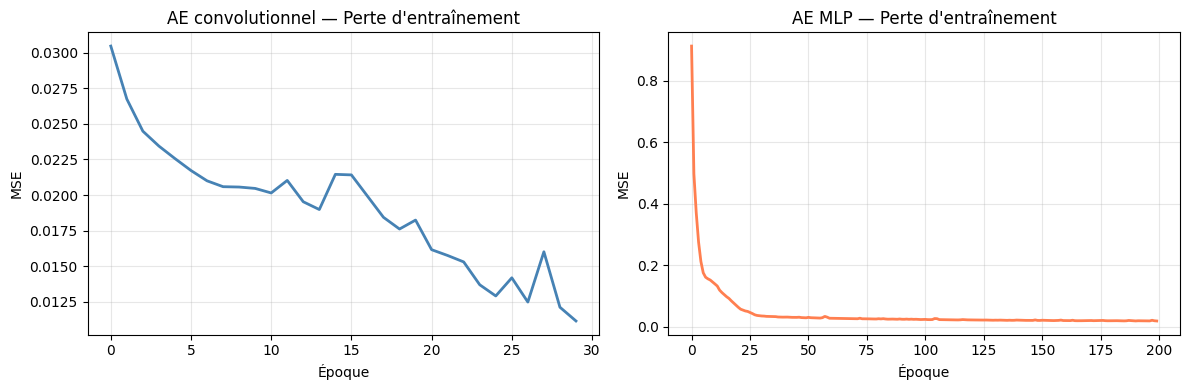

In [17]:
# Extraction des codes latents MLP
mlp_ae.eval()
with torch.no_grad():
    latent_mlp = mlp_ae.encode(tensor_mags.to(device)).cpu().numpy()   # (12524, 4)

print(f"Codes latents MLP : {latent_mlp.shape}")

# Courbes de perte des deux auto-encodeurs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses_conv, color='steelblue', lw=2)
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("MSE")
axes[0].set_title("AE convolutionnel — Perte d'entraînement")
axes[0].grid(True, alpha=0.3)

axes[1].plot(losses_mlp, color='coral', lw=2)
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("MSE")
axes[1].set_title("AE MLP — Perte d'entraînement")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ae_training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Régression avec les représentations latentes

On utilise les codes latents appris par les deux auto-encodeurs comme features pour prédire z :
- `latent_conv` (32-dim) : morphologie extraite par l'AE convolutionnel
- `latent_mlp`  (4-dim)  : structure de la photométrie extraite par l'AE MLP
- Combinaisons avec les couleurs classiques

In [18]:
print("=== Régression avec les codes latents ===")

ae_feature_sets = {
    "Latent AE Conv (32-dim)"             : latent_conv,
    "Latent AE MLP  (4-dim)"              : latent_mlp,
    "Latent AE Conv + Couleurs"           : np.hstack([colors, latent_conv]),
    "Latent AE MLP  + Couleurs"           : np.hstack([colors, latent_mlp]),
    "Latent AE Conv + AE MLP"             : np.hstack([latent_conv, latent_mlp]),
    "Couleurs + AE Conv + AE MLP"         : np.hstack([colors, latent_conv, latent_mlp]),
}

ae_results = {}
for name, X in ae_feature_sets.items():
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X[mask_train], y_train)
    r = evaluate(y_test, rf.predict(X[mask_test]), name)
    ae_results[name] = r

print("\n=== Référence ===")
evaluate(y_test, all_zphot[mask_test],             "ZPHOT classique")
rf_ref = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_ref.fit(colors[mask_train], y_train)
evaluate(y_test, rf_ref.predict(colors[mask_test]), "RF Couleurs seules")

=== Régression avec les codes latents ===
  Latent AE Conv (32-dim)                     R²=+0.2820  σ_NMAD=0.5047  η=0.78
  Latent AE MLP  (4-dim)                      R²=+0.3697  σ_NMAD=0.3955  η=0.74
  Latent AE Conv + Couleurs                   R²=+0.5613  σ_NMAD=0.4210  η=0.74
  Latent AE MLP  + Couleurs                   R²=+0.5257  σ_NMAD=0.3107  η=0.59
  Latent AE Conv + AE MLP                     R²=+0.3482  σ_NMAD=0.6082  η=0.70
  Couleurs + AE Conv + AE MLP                 R²=+0.5148  σ_NMAD=0.4250  η=0.74

=== Référence ===
  ZPHOT classique                             R²=+0.6609  σ_NMAD=0.0665  η=0.30
  RF Couleurs seules                          R²=+0.6037  σ_NMAD=0.2702  η=0.67


{'name': 'RF Couleurs seules',
 'r2': 0.6036712302158596,
 'nmad': np.float64(0.2701684007602381),
 'eta': np.float64(0.6666666666666666)}

## 12. Visualisation finale

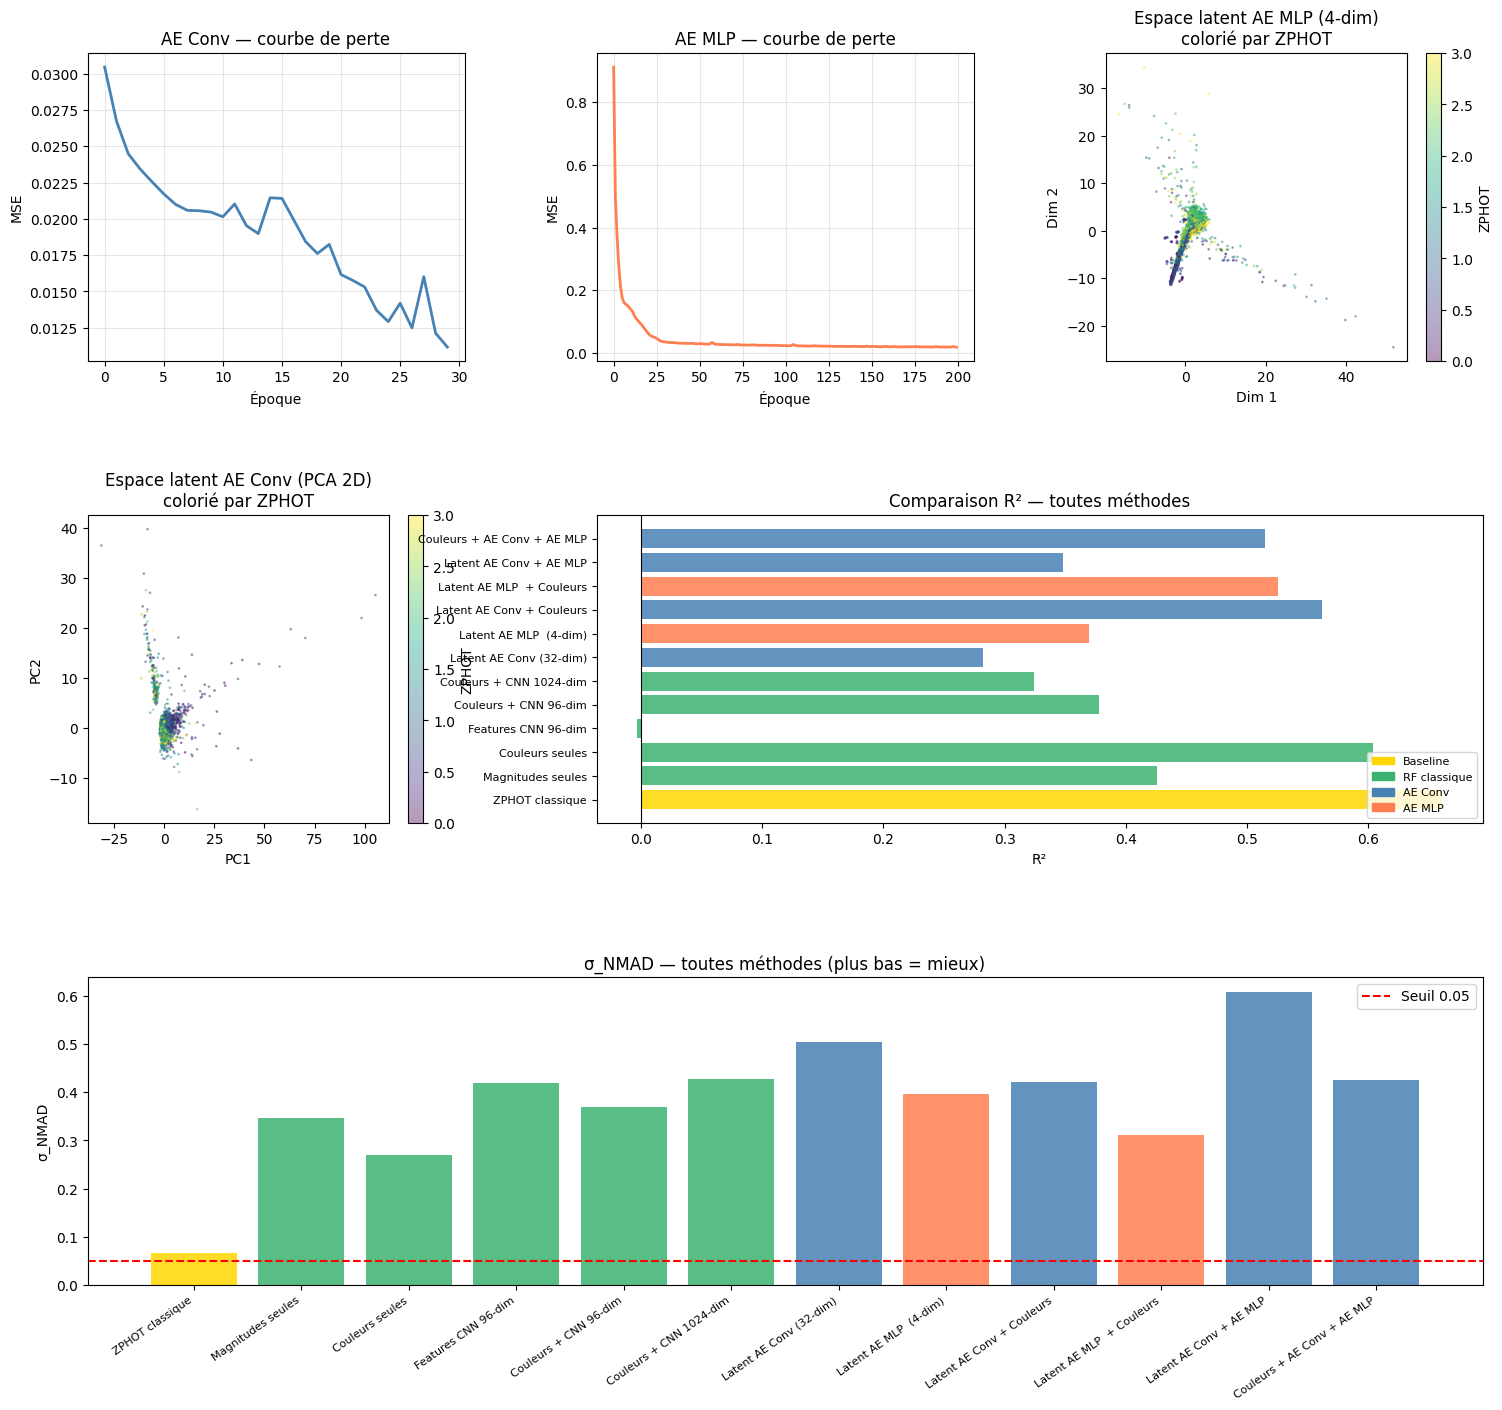

In [19]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── 1 : Courbe de perte AE conv ──
ax = fig.add_subplot(gs[0, 0])
ax.plot(losses_conv, color='steelblue', lw=2)
ax.set_xlabel("Époque"); ax.set_ylabel("MSE")
ax.set_title("AE Conv — courbe de perte")
ax.grid(True, alpha=0.3)

# ── 2 : Courbe de perte AE MLP ──
ax = fig.add_subplot(gs[0, 1])
ax.plot(losses_mlp, color='coral', lw=2)
ax.set_xlabel("Époque"); ax.set_ylabel("MSE")
ax.set_title("AE MLP — courbe de perte")
ax.grid(True, alpha=0.3)

# ── 3 : Espace latent AE MLP colorié par ZPHOT ──
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(latent_mlp[:, 0], latent_mlp[:, 1],
                c=all_zphot, cmap='viridis', s=1, alpha=0.4, vmin=0, vmax=3)
plt.colorbar(sc, ax=ax, label='ZPHOT')
ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
ax.set_title("Espace latent AE MLP (4-dim)\ncolorié par ZPHOT")

# ── 4 : Espace latent AE Conv PCA-2 colorié par ZPHOT ──
ax = fig.add_subplot(gs[1, 0])
lc_2d = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(latent_conv))
sc2 = ax.scatter(lc_2d[:, 0], lc_2d[:, 1],
                 c=all_zphot, cmap='viridis', s=1, alpha=0.4, vmin=0, vmax=3)
plt.colorbar(sc2, ax=ax, label='ZPHOT')
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Espace latent AE Conv (PCA 2D)\ncolorié par ZPHOT")

# ── 5 : R² comparaison toutes méthodes ──
ax = fig.add_subplot(gs[1, 1:])
all_methods = (
    [("ZPHOT classique",  r2_score(y_test, all_zphot[mask_test]))] +
    [(r["name"], r["r2"]) for r in rf_results.values()] +
    [(r["name"], r["r2"]) for r in ae_results.values()]
)
names_all = [m[0] for m in all_methods]
r2_all    = [m[1] for m in all_methods]
colors_bar = ['gold' if 'ZPHOT' in n else
              'steelblue' if 'AE Conv' in n else
              'coral' if 'AE MLP' in n else
              'mediumseagreen' for n in names_all]
y_pos = np.arange(len(names_all))
ax.barh(y_pos, r2_all, color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(names_all, fontsize=8)
ax.set_xlabel("R²")
ax.set_title("Comparaison R² — toutes méthodes")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='gold',         label='Baseline'),
    Patch(color='mediumseagreen', label='RF classique'),
    Patch(color='steelblue',    label='AE Conv'),
    Patch(color='coral',        label='AE MLP'),
], fontsize=8, loc='lower right')

# ── 6 : σ_NMAD comparaison ──
ax = fig.add_subplot(gs[2, :])
nmad_all = (
    [("ZPHOT classique",  sigma_nmad(y_test, all_zphot[mask_test]))] +
    [(r["name"], r["nmad"]) for r in rf_results.values()] +
    [(r["name"], r["nmad"]) for r in ae_results.values()]
)
names_nmad = [m[0] for m in nmad_all]
vals_nmad  = [m[1] for m in nmad_all]
colors_nmad = ['gold' if 'ZPHOT' in n else
               'steelblue' if 'AE Conv' in n else
               'coral' if 'AE MLP' in n else
               'mediumseagreen' for n in names_nmad]
x_pos = np.arange(len(names_nmad))
ax.bar(x_pos, vals_nmad, color=colors_nmad, alpha=0.85)
ax.axhline(0.05, color='red', linestyle='--', lw=1.5, label='Seuil 0.05')
ax.set_xticks(x_pos)
ax.set_xticklabels(names_nmad, rotation=35, ha='right', fontsize=8)
ax.set_ylabel("σ_NMAD")
ax.set_title("σ_NMAD — toutes méthodes (plus bas = mieux)")
ax.legend()

plt.savefig("resultats_finaux.png", dpi=150, bbox_inches='tight')
plt.show()

## 13. Bilan général

In [20]:
print("=" * 70)
print("BILAN GÉNÉRAL")
print("=" * 70)
print(f"\n  {'Méthode':<45}  R²       σ_NMAD   η")
print("  " + "-" * 70)

# Références
print("\n  -- Références --")
evaluate(y_test, all_zphot[mask_test], "ZPHOT classique")

# Meilleur RF classique
print("\n  -- Meilleurs RF classiques --")
best_rf = max(rf_results.values(), key=lambda r: r['r2'])
evaluate(y_test,
         RandomForestRegressor(100, random_state=42, n_jobs=-1)
         .fit(feature_sets_rf[best_rf['name']][mask_train], y_train)
         .predict(feature_sets_rf[best_rf['name']][mask_test]),
         f"RF — {best_rf['name']}")

# Meilleurs AE
print("\n  -- Auto-encodeurs --")
best_ae = max(ae_results.values(), key=lambda r: r['r2'])
for name, r in ae_results.items():
    evaluate(y_test,
             RandomForestRegressor(100, random_state=42, n_jobs=-1)
             .fit(ae_feature_sets[name][mask_train], y_train)
             .predict(ae_feature_sets[name][mask_test]),
             name)

print("\n" + "=" * 70)
print("Note : avec 27 objets ZSPEC, les IC bootstrap sont larges.")
print("Utiliser σ_NMAD comme critère principal, plus robuste que R².")

BILAN GÉNÉRAL

  Méthode                                        R²       σ_NMAD   η
  ----------------------------------------------------------------------

  -- Références --
  ZPHOT classique                             R²=+0.6609  σ_NMAD=0.0665  η=0.30

  -- Meilleurs RF classiques --
  RF — Couleurs seules                        R²=+0.6037  σ_NMAD=0.2702  η=0.67

  -- Auto-encodeurs --
  Latent AE Conv (32-dim)                     R²=+0.2820  σ_NMAD=0.5047  η=0.78
  Latent AE MLP  (4-dim)                      R²=+0.3697  σ_NMAD=0.3955  η=0.74
  Latent AE Conv + Couleurs                   R²=+0.5613  σ_NMAD=0.4210  η=0.74
  Latent AE MLP  + Couleurs                   R²=+0.5257  σ_NMAD=0.3107  η=0.59
  Latent AE Conv + AE MLP                     R²=+0.3482  σ_NMAD=0.6082  η=0.70
  Couleurs + AE Conv + AE MLP                 R²=+0.5148  σ_NMAD=0.4250  η=0.74

Note : avec 27 objets ZSPEC, les IC bootstrap sont larges.
Utiliser σ_NMAD comme critère principal, plus robuste que R².
